In [8]:
def generate_prizes(n_ferraris=1, n_goats=2):
    prizes = [1] * n_ferraris + [0] * n_goats
    return prizes

In [11]:
prizes = generate_prizes(1, 10)

In [26]:
from random import shuffle, choice

In [13]:
shuffle(prizes)

In [14]:
prizes

[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]

In [15]:
choosen_door = None

In [16]:
# the player chooses the door

In [23]:
def choose_goat_door(prizes, chosen_door):
    possible_doors = range(len(prizes))
    possible_doors = [door for door in possible_doors if door != chosen_door and prizes[door] != 1]
    revealed_door = choice(possible_doors)
    return revealed_door
    

In [20]:
def choose_door(door):
    global chosen_door
    chosen_door = door
    

In [43]:
def pick_door(n_doors):
    return choice(list(range(n_doors)))

In [47]:
def switch_door(n_doors, user_chosen_door, revealed_door):
    possible_doors = range(n_doors)
    possible_doors = [door for door in possible_doors if door != user_chosen_door and
                                                         door != revealed_door]
    return choice(possible_doors)

In [52]:
def play_match(n_ferrari, n_goats, strategy="switch"):
    global prizes, chosen_door
    prizes = generate_prizes(n_ferrari, n_goats)
    shuffle(prizes)
    choose_door(pick_door(len(prizes)))
    print("you chose", chosen_door)
    revealed_door = choose_goat_door(prizes, chosen_door)
    print("behind door", revealed_door, "there's a goat!")
    
    if strategy == "switch":
        choose_door(switch_door(len(prizes), chosen_door, revealed_door))
    
    print("you chose door", chosen_door)
    print("prizes were", prizes)
    if prizes[chosen_door] == 1:
        print("you won!!!")
        return 1
    else:
        print("you lost!!")
        return 0
    
        
    

In [65]:
play_match(10, 10, "stick")

you chose 14
behind door 3 there's a goat!
you chose door 14
prizes were [1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1]
you lost!!


0

In [67]:
matches = [play_match(1, 2, "switch") for x in range(1000)]

you chose 1
behind door 0 there's a goat!
you chose door 2
prizes were [0, 1, 0]
you lost!!
you chose 2
behind door 0 there's a goat!
you chose door 1
prizes were [0, 1, 0]
you won!!!
you chose 0
behind door 2 there's a goat!
you chose door 1
prizes were [1, 0, 0]
you lost!!
you chose 1
behind door 0 there's a goat!
you chose door 2
prizes were [0, 0, 1]
you won!!!
you chose 1
behind door 0 there's a goat!
you chose door 2
prizes were [0, 0, 1]
you won!!!
you chose 2
behind door 1 there's a goat!
you chose door 0
prizes were [0, 0, 1]
you lost!!
you chose 1
behind door 0 there's a goat!
you chose door 2
prizes were [0, 0, 1]
you won!!!
you chose 0
behind door 2 there's a goat!
you chose door 1
prizes were [1, 0, 0]
you lost!!
you chose 1
behind door 2 there's a goat!
you chose door 0
prizes were [0, 1, 0]
you lost!!
you chose 0
behind door 2 there's a goat!
you chose door 1
prizes were [0, 1, 0]
you won!!!
you chose 1
behind door 2 there's a goat!
you chose door 0
prizes were [0, 1, 0]

In [69]:
sum(matches)

648

In [70]:
%matplotlib inline

In [72]:
from matplotlib import pyplot as plt

([<matplotlib.patches.Wedge at 0x129b2e020>,
 [Text(-0.4932215435906337, 0.9832255636109513, 'won'),
  Text(0.4932215435906331, -0.9832255636109516, 'lost')],
 [Text(-0.26902993286761834, 0.5363048528787007, '64.8%'),
  Text(0.269029932867618, -0.5363048528787008, '35.2%')])

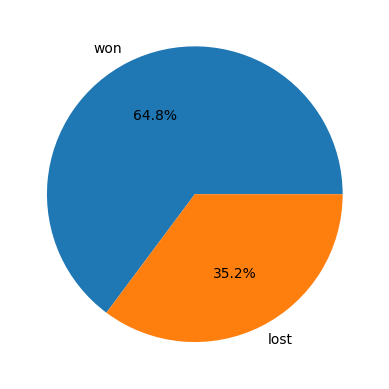

In [76]:
plt.pie([sum(matches), len(matches) - sum(matches)], labels=["won", "lost"], autopct='%1.1f%%')